## Question: "Which readout pattern is most efficient?"

### Some NIRCam Docs
- [Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-detector-overview/nircam-detector-readout-patterns#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-strategies/nircam-imaging-recommended-strategies#gsc.tab=0)


In [ ]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"
os.environ["PSF_DIR"] = "../../data/pandeia_psfs-2026.7rc1-jwst"
os.environ["PYSYN_CDBS"] = "../../data/grp/redcat/trds"

from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation
import matplotlib.pyplot as plt
import numpy as np
import math

# Observing parameters
telescope = 'jwst'
instrument = 'nircam'
mode = 'lw_imaging'
filter = 'f356w'

# Science goal: reach this depth at this S/N
target_mag = 28.5 # faint source
target_snr = 5.0

# Readout patterns to compare (shallow -> deep)
readout_patterns = ['rapid', 'bright2', 'shallow4', 'medium8', 'deep8']

# Search bounds for the (ngroup, nint) recipe
min_groups, max_groups = 2, 20
max_nint = 20
max_single_int = 1000 # s, NIRCam cosmic-ray limit
nexp = 1

In [3]:
def build_calc(readout, ngroup, nint):
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['filter'] = filter
    det = calc['configuration']['detector']
    det['readout_pattern'] = readout
    det['ngroup'] = ngroup
    det['nint'] = nint
    det['nexp'] = nexp
    scene = calc['scene'][0]
    scene['shape']['geometry'] = 'point'
    scene['spectrum']['normalization'] = {
        'type': 'jwst', 'bandpass': f'nircam,{mode},{filter}',
        'norm_flux': target_mag, 'norm_fluxunit': 'abmag'}
    scene['spectrum']['sed'] = {'sed_type': 'flat', 'unit': 'fnu'}
    calc['background_level'] = 'low'
    return calc

def min_time_for_snr(readout):
    """Minimum total exposure time for this readout to reach target_snr at target_mag.

    For each integration length (ngroup, capped by the single-integration limit),
    estimate the stacks (nint) needed via S/N ~ sqrt(nint), verify, trim any
    overshoot, and keep the least-time recipe.
    """
    best = None
    for ngroup in range(min_groups, max_groups + 1):
        r1 = perform_calculation(build_calc(readout, ngroup, 1))
        single_int = r1['information']['exposure_specification']['exposure_time']  # nint=1
        if single_int > max_single_int:
            break  # longer integrations only exceed the limit
        snr1 = r1['scalar']['sn']
        if snr1 <= 0:
            continue
        nint = min(max_nint, max(1, math.ceil((target_snr / snr1) ** 2)))
        rep = perform_calculation(build_calc(readout, ngroup, nint))
        while rep['scalar']['sn'] < target_snr and nint < max_nint:   # estimate fell short
            nint += 1
            rep = perform_calculation(build_calc(readout, ngroup, nint))
        while nint > 1:                                               # trim overshoot
            rd = perform_calculation(build_calc(readout, ngroup, nint - 1))
            if rd['scalar']['sn'] < target_snr:
                break
            nint -= 1
            rep = rd
        if rep['scalar']['sn'] >= target_snr:
            t = rep['information']['exposure_specification']['total_exposure_time']
            if best is None or t < best['time']:
                best = dict(time=t, ngroup=ngroup, nint=nint, snr=rep['scalar']['sn'])
    return best

rapid     -> min time    4499 s (1.25 h)  ngroup=20, nint=20, S/N=5.00
bright2   -> min time    3511 s (0.98 h)  ngroup=20, nint=8, S/N=5.03
shallow4  -> min time    3425 s (0.95 h)  ngroup=16, nint=4, S/N=5.11
medium8   -> min time    3382 s (0.94 h)  ngroup=8, nint=4, S/N=5.09
deep8     -> min time    3672 s (1.02 h)  ngroup=3, nint=7, S/N=5.29

=== Most efficient for m=28.5 at S/N=5.0 (f356w): medium8 (3382 s) ===
  rapid    :    4499 s  (+33% vs best)
  bright2  :    3511 s  (+4% vs best)
  shallow4 :    3425 s  (+1% vs best)
  medium8  :    3382 s  (+0% vs best)
  deep8    :    3672 s  (+9% vs best)


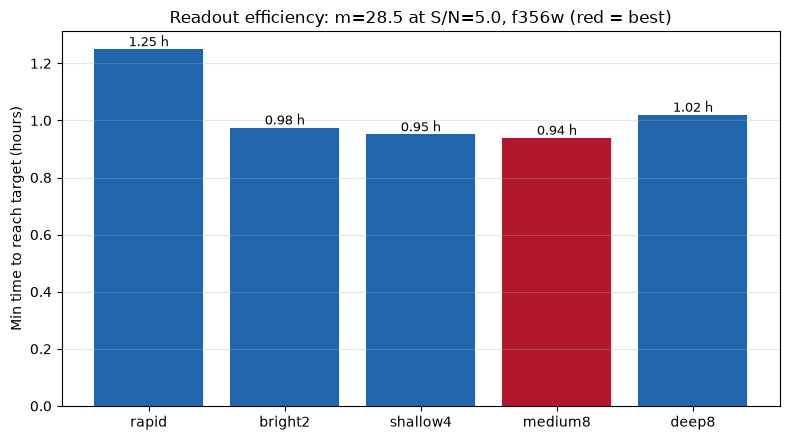

In [4]:
# Compare all patterns
results = {}
for ro in readout_patterns:
    results[ro] = min_time_for_snr(ro)
    b = results[ro]
    if b:
        print(f"{ro:9} -> min time {b['time']:7.0f} s ({b['time']/3600:.2f} h)  "
              f"ngroup={b['ngroup']}, nint={b['nint']}, S/N={b['snr']:.2f}")
    else:
        print(f"{ro:9} -> target not reached within limits")

valid = {k: v for k, v in results.items() if v}
best_ro = min(valid, key=lambda k: valid[k]['time'])
best_t = valid[best_ro]['time']

print(f"\n=== Most efficient for m={target_mag} at S/N={target_snr} ({filter}): "
      f"{best_ro} ({best_t:.0f} s) ===")
for ro in readout_patterns:
    if results[ro]:
        pct = 100 * (results[ro]['time'] / best_t - 1)
        print(f"  {ro:9}: {results[ro]['time']:7.0f} s  (+{pct:.0f}% vs best)")

# Bar chart
labels = [ro for ro in readout_patterns if results[ro]]
times = np.array([results[ro]['time'] for ro in labels])
colors = ['#b2182b' if results[ro]['time'] == best_t else '#2166ac' for ro in labels]

plt.figure(figsize=(8, 4.5))
plt.bar(labels, times / 3600, color=colors)
plt.ylabel('Min time to reach target (hours)')
plt.title(f'Readout efficiency: m={target_mag} at S/N={target_snr}, {filter} (red = best)')
plt.grid(axis='y', alpha=0.3)
for i, t in enumerate(times):
    plt.text(i, t / 3600, f'{t/3600:.2f} h', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()